# MINTERPY/n-dimensional fitting for PCO FA neutral loss fragmentation data

In [1]:
# basic python packages
import numpy as np
import pandas as pd

# specific python packages
import minterpy as mp
import cvxpy as cp
# added by Damar for handling equations
import sympy as sp

# visualisation tools
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.widgets  import RectangleSelector
from minterpy.core.utils import get_exponent_matrix
import matplotlib.patches as patches

# others
import minterpy_functions as mf
import pickle

## PCO CO2 FANL data fitting

In [2]:
# import FA anion fragment data via csv
df = pd.read_csv(r"./frag_data/220421_PCO_sn2FANL.csv").dropna(axis=1)
cols = ['CE', 'FA_C', 'FA_DB', 'FA_iso']

# analyte information to_numpy()
sample_points = df[cols].to_numpy()
function_vals = df['norm_Intensity'].to_numpy()

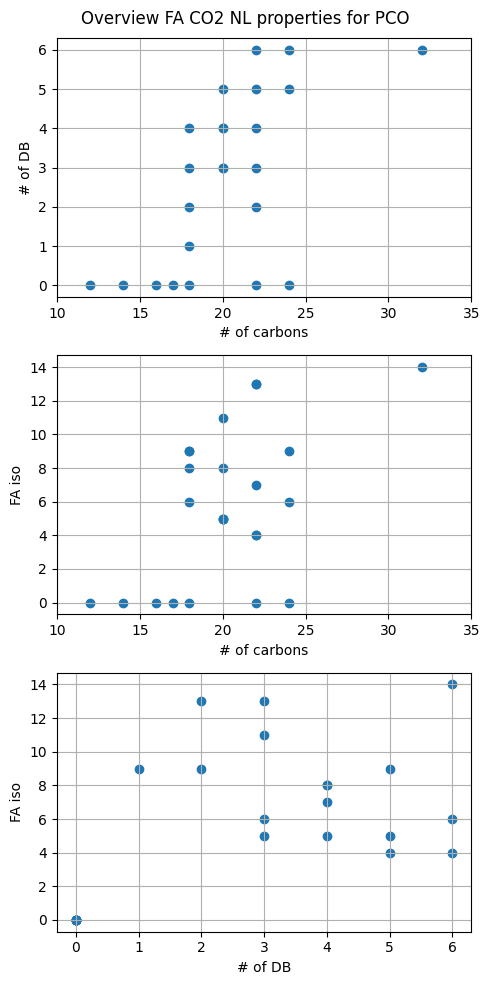

In [3]:
## get dataframe with needed properties
overview_df = df[['FA_C', 'FA_DB', 'FA_iso']].drop_duplicates()

fig, ax = plt.subplots(3,1, figsize=(5,10))

fig.suptitle('Overview FA CO2 NL properties for PCO')

# plot number of carbons vs number of DB
ax = plt.subplot(3,1,1) 
plt.scatter(overview_df.FA_C, overview_df.FA_DB)
ax.set_xlim(10,35)
ax.set_xlabel('# of carbons')
ax.set_ylabel('# of DB')
ax.grid(which='both')

# plot number of carbons vs DB position
ax = plt.subplot(3,1,2) 
plt.scatter(overview_df.FA_C, overview_df.FA_iso)
ax.set_xlim(10,35)
ax.set_xlabel('# of carbons')
ax.set_ylabel('FA iso')
ax.grid(which='both')

# plot number of DB vs DB position
ax = plt.subplot(3,1,3) 
plt.scatter(overview_df.FA_DB, overview_df.FA_iso)
ax.set_xlabel('# of DB')
ax.set_ylabel('FA iso')
ax.grid(which='both')

plt.tight_layout()
plt.show()

In [4]:
a_uni = np.array(overview_df.sort_values(by=['FA_C', 'FA_DB', 'FA_iso']))
a_uni

array([[12,  0,  0],
       [14,  0,  0],
       [16,  0,  0],
       [17,  0,  0],
       [18,  0,  0],
       [18,  1,  9],
       [18,  2,  9],
       [18,  3,  6],
       [18,  4,  8],
       [20,  3,  5],
       [20,  3, 11],
       [20,  4,  5],
       [20,  4,  8],
       [20,  5,  5],
       [22,  0,  0],
       [22,  2, 13],
       [22,  3, 13],
       [22,  4,  7],
       [22,  5,  4],
       [22,  6,  4],
       [24,  0,  0],
       [24,  5,  9],
       [24,  6,  6],
       [32,  6, 14]], dtype=int64)

## MINTERPY/n-dimensional fitting of PCO FA fragment data

In [5]:
sparse_poly_model = mf.lasso_fit_data(sample_points,
                                       function_vals, 
                                       poly_degree_along=[8,1,1,1], ## PCO FA with 8.3.2.2; degree could be lower here => no major changes
                                       weighted=True)

c:\Users\schuhmann\AppData\Local\Programs\Python\Python312\Lib\site-packages\minterpy\schemes\barycentric\operators.py:47: UserWarning: building a full transformation matrix from a barycentric transformation. this is inefficient.
  warn(


Optimizer result : 211.80529094501853


L_2 error of fitting SYM dataset = 0.4004182715838269
L_inf error of fitting SYM dataset = 15.240094240218246


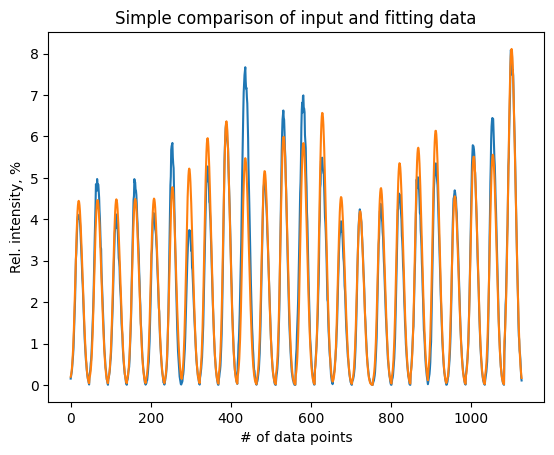

In [6]:
lower_bounds = np.round(np.amin(sample_points, axis=0))
upper_bounds = np.round(np.amax(sample_points, axis=0))+1.0

eval_vals = mf.poly_evaluate_at(sparse_poly_model, sample_points, lower_bounds, upper_bounds)

abs_errs = pow(2,eval_vals) - function_vals
rel_errs = np.divide(abs_errs, function_vals)

L2_error = np.linalg.norm(rel_errs, 1)/len(rel_errs)
Linf_error = np.max(np.abs(rel_errs))

print(f"L_2 error of fitting SYM dataset = {L2_error}")
print(f"L_inf error of fitting SYM dataset = {Linf_error}")

plt.title("Simple comparison of input and fitting data")
plt.plot(function_vals)
plt.plot(pow(2,eval_vals))
plt.xlabel("# of data points")
plt.ylabel("Rel. intensity, %")
plt.show()

## Visualization of fitting data/results

### Comparison of fragment intensities : measured vs calculated via MINTERPY/ndim fitting

#### Comparison for saturated FA

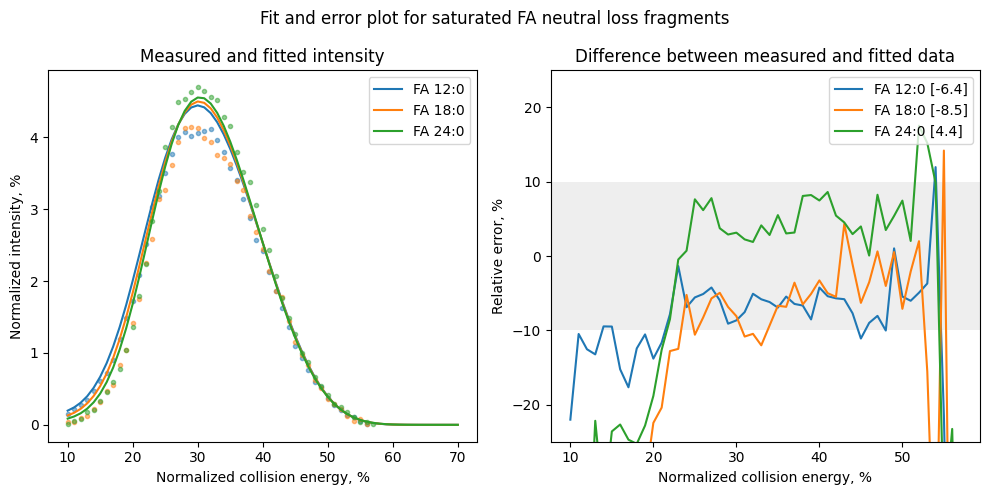

In [7]:
# color definition for plots
colors = [('tab:blue', '#1f77b4'), ('tab:orange', '#ff7f0e'), ('tab:green', '#2ca02c'), ('tab:red', '#d62728'), ('tab:purple', '#9467bd'), ('tab:brown', '#8c564b'), ('tab:pink', '#e377c2'), ('tab:gray', '#7f7f7f'), ('tab:olive', '#bcbd22'), ('tab:cyan', '#17becf')]

nce = [10,70] # range of nce
FA_oi = [[12, 0, 0], [18, 0, 0], [24, 0, 0]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Fit and error plot for saturated FA neutral loss fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()


#### Comparison for FAs with 18 carbons and different DBs

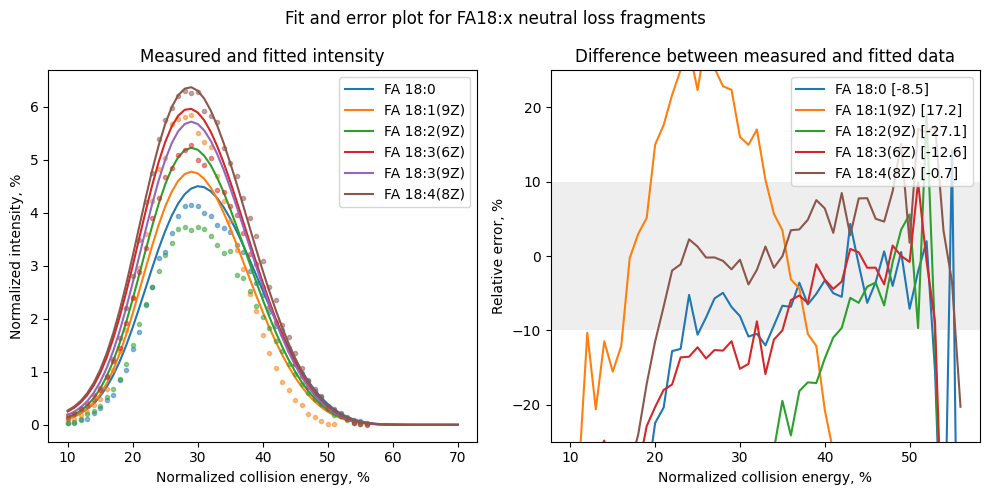

In [8]:
nce = [10,70] # range of nce
FA_oi = [[18, 0, 0], [18, 1, 9], [18, 2, 9], [18, 3, 6], [18, 3, 9], [18, 4, 8]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Fit and error plot for FA18:x neutral loss fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()


#### Comparison for FAs with 20 carbons and different DBs

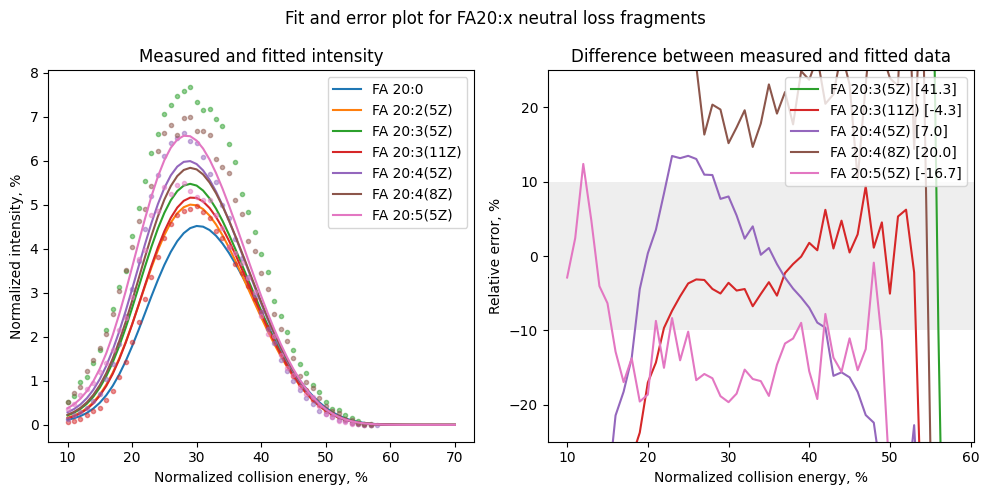

In [9]:
nce = [10,70] # range of nce
FA_oi = [[20, 0, 0], [20, 2, 5], [20, 3, 5], [20, 3, 11], [20, 4, 5], [20, 4, 8], [20, 5, 5]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Fit and error plot for FA20:x neutral loss fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()


#### Comparison for FAs with 22 carbons and different DBs

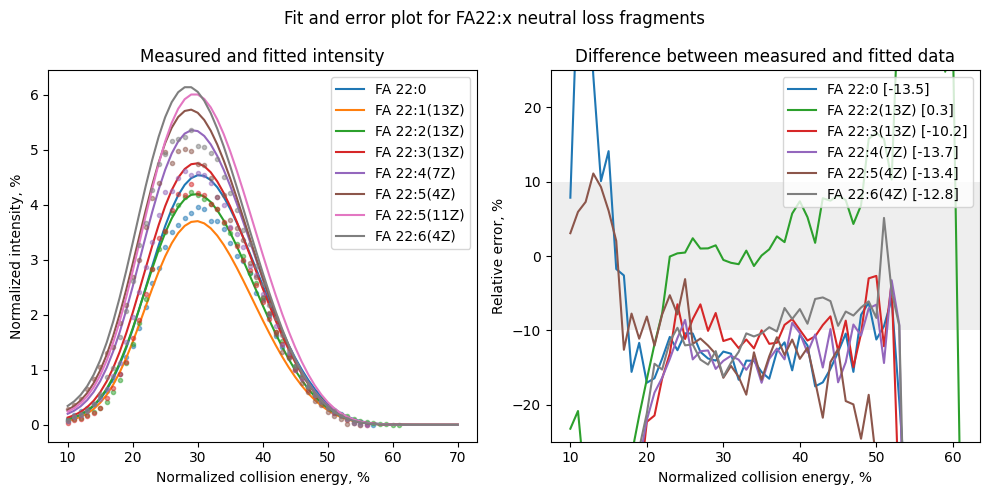

In [10]:
nce = [10,70] # range of nce
FA_oi = [[22, 0, 0], [22, 1, 13], [22, 2, 13], [22, 3, 13], [22, 4, 7], [22, 5, 4], [22, 5, 11], [22, 6, 4]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle("Fit and error plot for FA22:x neutral loss fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()


#### Comparison for FAs with 22-32 carbons and 6 DBs

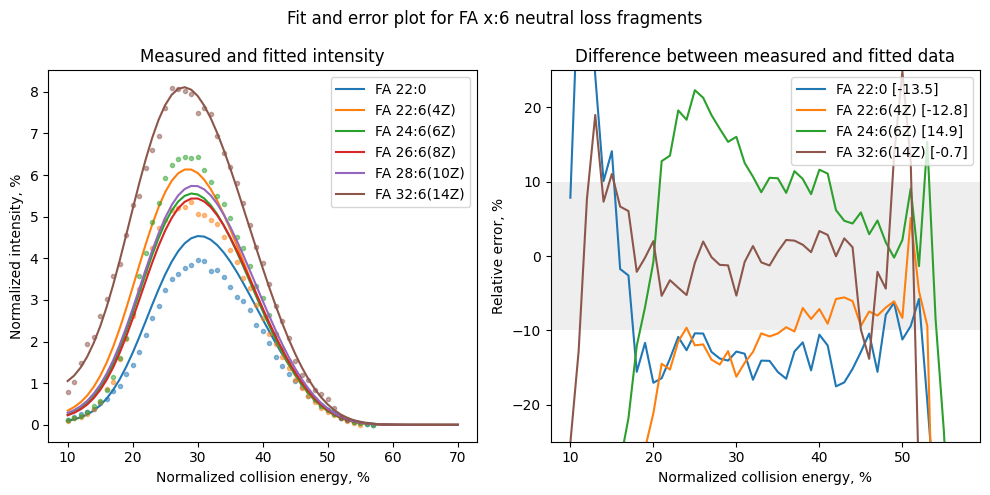

In [11]:
nce = [10,70] # range of nce
FA_oi = [[22, 0, 0], [22, 6, 4], [24, 6, 6], [26, 6, 8], [28, 6, 10], [32, 6, 14]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle("Fit and error plot for FA x:6 neutral loss fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Handling MINTERPYs ndim equations

### Convertion of NewtonPolynomials for 'equation' 

In [12]:
# Transformation of NewtonPolynomials to Canonical Form
model_can = mp.get_transformation(sparse_poly_model, mp.CanonicalPolynomial)()

trimmed_coeffs = model_can.coeffs.copy()

# conditional coefficient modification, if needed
# trimmed_coeffs[np.where((trimmed_coeffs<1e0) & (trimmed_coeffs>-1e0))] = 0.0
# trimmed_coeffs = np.around(trimmed_coeffs, 2)

model_can.coeffs = trimmed_coeffs
model_eqn = mf.mp_to_sympy(model_can)

# conversion to equation
model_eqn

Poly(0.993143616104734*x_0**8 - 1.71356572051564e-14*x_0**7*x_1*x_2*x_3 - 2.36049605522639e-14*x_0**7*x_1*x_2 + 4.01388242394506e-14*x_0**7*x_1*x_3 - 3.55271367880043e-15*x_0**7*x_1 - 1.03664159168999e-14*x_0**7*x_2*x_3 + 7.64840895694436e-15*x_0**7*x_2 + 0.00873311885390395*x_0**7*x_3 - 1.00073976134924*x_0**7 + 9.7419793886545e-16*x_0**6*x_1*x_2*x_3 + 2.78059701844798e-15*x_0**6*x_1*x_2 - 4.86476268060635e-15*x_0**6*x_1*x_3 + 7.32747196252591e-15*x_0**6*x_1 + 1.54835694599041e-14*x_0**6*x_2*x_3 - 1.26837067842241e-14*x_0**6*x_2 + 4.65280225933068e-15*x_0**6*x_3 - 5.3823461314739e-14*x_0**6 - 2.33727279111406e-14*x_0**5*x_1*x_2*x_3 + 4.33380731346826e-14*x_0**5*x_1*x_2 - 2.33931106810872e-14*x_0**5*x_1*x_3 - 2.67081933934423e-15*x_0**5*x_1 - 0.242660014117674*x_0**5*x_2*x_3 - 3.88195550823796e-14*x_0**5*x_2 + 1.69662857699219e-15*x_0**5*x_3 + 3.01821738989952e-13*x_0**5 + 3.56415132294417e-15*x_0**4*x_1*x_2*x_3 - 1.53846047930849e-15*x_0**4*x_1*x_2 - 1.73796565527278e-14*x_0**4*x_1*x_

### Convertion of 'equation' to NewtonPolynomials

In [13]:
# conversion of pco_model_eqn to new "sparse_poly_model" called "test_equation" to see if we get back intensity values
test_poly_model = mf.sympy_to_mp(model_eqn, target_basis=mp.NewtonPolynomial)

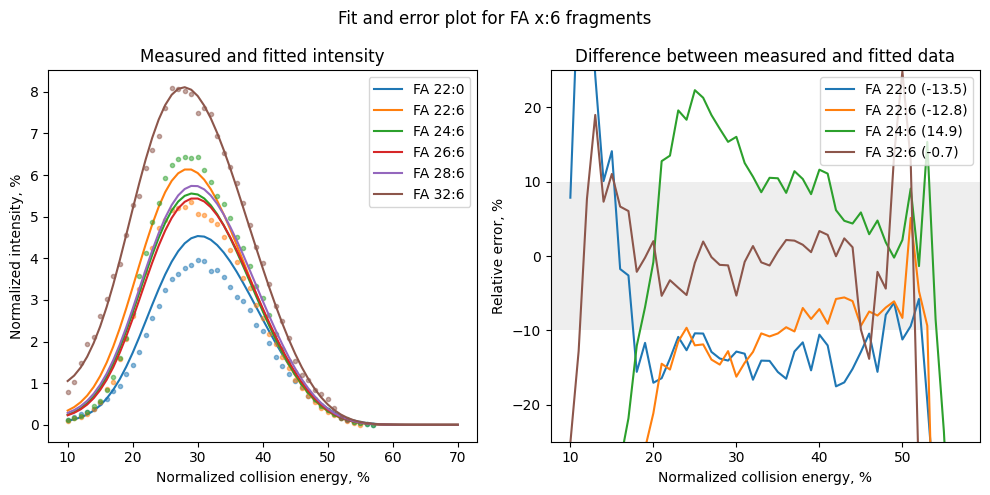

In [14]:
nce = [10,70] # range of nce
FA_oi = [[22, 0, 0], [22, 6, 4], [24, 6, 6], [26, 6, 8], [28, 6, 10], [32, 6, 14]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))

fig.suptitle("Fit and error plot for FA x:6 fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(test_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} ({round(av, 1)})', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')
    

plt.tight_layout()
plt.show()

### Saving/export of polynomial functions as eg pickle

In [15]:
# write polynomial coefficients and exponents to dictionary for export
poly_info = {'coeffs': sparse_poly_model.coeffs, 'exponents': sparse_poly_model.multi_index.exponents, 'lower_bounds': lower_bounds, 'upper_bounds': upper_bounds}

# Storing the polynomial object in a file
pickle.dump(poly_info, open('./polynomials/240916_PCO_sn2FANL_poly.pkl', 'ab'))

In [16]:
poly_info

{'coeffs': array([-1.05131401e+01, -7.71423056e+00, -6.12884369e+00, -4.25863951e+00,
        -2.19787443e+00, -2.04513104e+00,  1.63515794e+00, -9.19278204e-02,
         9.93143616e-01, -7.60204999e-01,  2.80703440e+00, -2.15015078e+00,
         8.37839309e-01,  6.12843110e-14,  0.00000000e+00,  8.88178420e-15,
        -4.26325641e-14, -2.53699678e-01, -1.94076987e+00,  9.47676140e-01,
        -2.57045031e-01, -9.41469125e-14,  2.42660014e-01, -2.84217094e-14,
         2.13162821e-14, -5.56161073e-01,  1.05511806e+00, -8.88586639e-01,
         1.04805054e-13, -1.99840144e-15,  5.63993297e-14, -8.88178420e-16,
        -3.55271368e-15,  8.17410766e-01,  2.68798123e+00, -1.45286753e+00,
         4.89132246e-01,  8.70414851e-14, -2.28281400e-01,  2.13162821e-14,
         8.73311885e-03, -1.24842994e-01, -2.40726288e+00,  1.45286753e+00,
        -8.37839309e-01, -2.04281037e-14, -7.10542736e-15, -8.88178420e-16,
         1.77635684e-14,  1.26163663e+00,  1.64870191e+00, -1.91303391e-01,
  